

**Тема моделирования:** пункт выдачи заказов.

В работе рассматривается пункт выдачи заказов, в котором есть одно окно
Если клиент приходит, когда окно свободно, его заказ выдается
Если в момент прихода окно занято другим клиентом, то новый клиент получает отказ и уходит

### Параметры модели
- $\lambda$ — интенсивность входящего потока клиентов
- $\mu$ — интенсивность обслуживания
- $T$ — время моделирования

### Состояния системы
состояния окна выдачи
- S_0 - свободно
- S_1 - занято

### Логика
1. клиенты приходят рандомно и если сотрудник свободен, клиент подходит на обслуживание
2. Если оператор занят, клиент не ждет и уходит
3. После завершения обслуживания окно снова становится свободным

### Исследуемые показатели
В ходе моделирования определяются:
- количество поступивших клиентов
- количество обслуженных клиентов
- количество потерянных клиентов
- вероятность отказа
- относительная пропускная способность
- коэффициент загрузки пункта выдачи



## 2. Алгоритм работы модели

### Порядок моделирования
1. В начальный момент времени система свободна
2. Генерируется момент прихода следующего клиента по экспоненциальному распределению с параметром $\lambda$.
3. Если клиент приходит в свободную систему, начинается обслуживание и генерируется момент его окончания по экспоненциальному распределению с параметром $\mu$.
4. Если в момент прихода канал занят, фиксируется отказ и уход его домой
5. После завершения обслуживания канал освобождается
6. Процесс повторяется до достижения времени моделирования $T$


In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:

def simulate_pickup_point(lmbda, mu, T, seed=None):
    rng = np.random.default_rng(seed)

    current_time = 0.0
    next_arrival = rng.exponential(1 / lmbda)
    next_departure = np.inf

    busy = False
    arrived = 0
    served = 0
    lost = 0

    busy_start_time = None
    total_busy_time = 0.0

    while True:
        if next_arrival <= next_departure:
            current_time = next_arrival
            if current_time > T:
                break

            arrived += 1

            if not busy:
                busy = True
                busy_start_time = current_time
                service_time = rng.exponential(1 / mu)
                next_departure = current_time + service_time
            else:
                lost += 1

            next_arrival = current_time + rng.exponential(1 / lmbda)
        else:
            current_time = next_departure
            if current_time > T:
                break

            served += 1
            total_busy_time += current_time - busy_start_time
            busy = False
            busy_start_time = None
            next_departure = np.inf

    if busy and busy_start_time is not None:
        total_busy_time += max(0.0, T - busy_start_time)

    refusal_prob = lost / arrived if arrived else 0.0
    service_prob = served / arrived if arrived else 0.0
    busy_coeff = total_busy_time / T

    return {
        "lambda": lmbda,
        "mu": mu,
        "T": T,
        "arrived": arrived,
        "served": served,
        "lost": lost,
        "chance_otkaz": refusal_prob,
        "propusk": service_prob,
        "zagruz": busy_coeff,
    }


def testrun(lmbda, mu):
    refusal_prob = lmbda / (lmbda + mu)
    service_prob = mu / (lmbda + mu)
    absolute_capacity = lmbda * service_prob
    busy_coeff = refusal_prob

    return {
        "chance_otkaz_teoria": refusal_prob,
        "propusk_teoria": service_prob,
        "absolute_capacity_theor": absolute_capacity,
        "zagruz_theor": busy_coeff,
    }



## 3. Эксперимент для заданных параметров

Ниже приведен запуск модели для базового набора параметров:
- $\lambda = 8$ клиентов в час;
- $\mu = 10$ клиентов в час;
- $T = 1000$ часов.


In [17]:

lmbda = 8
mu = 10
T = 1000

exp_result = simulate_pickup_point(lmbda, mu, T, seed=42)
theor_result = testrun(lmbda, mu)

arrived_theor = lmbda * T
served_theor = arrived_theor * theor_result["propusk_teoria"]
lost_theor = arrived_theor * theor_result["chance_otkaz_teoria"]

summary_df = pd.DataFrame([
    ["Количество поступивших клиентов", exp_result["arrived"], arrived_theor],
    ["Количество обслуженных клиентов", exp_result["served"], served_theor],
    ["Количество потерянных клиентов", exp_result["lost"], lost_theor],
    ["Вероятность отказа", exp_result["chance_otkaz"], theor_result["chance_otkaz_teoria"]],
    ["Относительная пропускная способность", exp_result["propusk"], theor_result["propusk_teoria"
                                                                                 ""]],
    ["Коэффициент загрузки", exp_result["zagruz"], theor_result["zagruz_theor"]],
], columns=["Показатель", "Эксперимент", "Теория"])

summary_df


,Показатель,Эксперимент,Теория
0,Количество поступивших клиентов,8019.000000,8000.000000
1,Количество обслуженных клиентов,4462.000000,4444.444444
2,Количество потерянных клиентов,3557.000000,3555.555556
3,Вероятность отказа,0.443572,0.444444
4,Относительная пропускная способность,0.556428,0.555556
5,Коэффициент загрузки,0.445979,0.444444



## 4. Серия экспериментов

Для анализа  интенсивности входящего потока изменим значение $\lambda$ от 1 до 10 при фиксированном $\mu = 7$.


In [18]:

lambdas = np.arange(1, 11)
mu = 7
T = 1000

rows = []
exp_refusal = []
theor_refusal = []

for lmbda in lambdas:
    exp_result = simulate_pickup_point(lmbda, mu, T, seed=42)
    theor_result = testrun(lmbda, mu)

    exp_refusal.append(exp_result["chance_otkaz"])
    theor_refusal.append(theor_result["chance_otkaz_teoria"])

    rows.append({
        "λ": lmbda,
        "μ": mu,
        "Поступило": exp_result["arrived"],
        "Обслужено": exp_result["served"],
        "Потеряно": exp_result["lost"],
        "Pотк (эксп)": exp_result["chance_otkaz"],
        "Pотк (теор)": theor_result["chance_otkaz_teoria"],
        "Загрузка (эксп)": exp_result["zagruz"],
        "Загрузка (теор)": theor_result["zagruz_theor"],
    })

experiments_df = pd.DataFrame(rows)
experiments_df


,λ,μ,Поступило,Обслужено,Потеряно,Pотк (эксп),Pотк (теор),Загрузка (эксп),Загрузка (теор)
0,1,7,969,860,109,0.112487,0.125000,0.125321,0.125000
1,2,7,2012,1560,452,0.224652,0.222222,0.225841,0.222222
2,3,7,3064,2155,909,0.296671,0.300000,0.307811,0.300000
3,4,7,4040,2589,1451,0.359158,0.363636,0.361898,0.363636
4,5,7,5134,2969,2165,0.421698,0.416667,0.427946,0.416667
5,6,7,6093,3268,2824,0.463483,0.461538,0.467040,0.461538
6,7,7,7026,3499,3527,0.501993,0.500000,0.492980,0.500000
7,8,7,8001,3717,4284,0.535433,0.533333,0.525303,0.533333
8,9,7,9037,3948,5089,0.563129,0.562500,0.559301,0.562500
9,10,7,9966,4146,5819,0.583885,0.588235,0.582268,0.588235


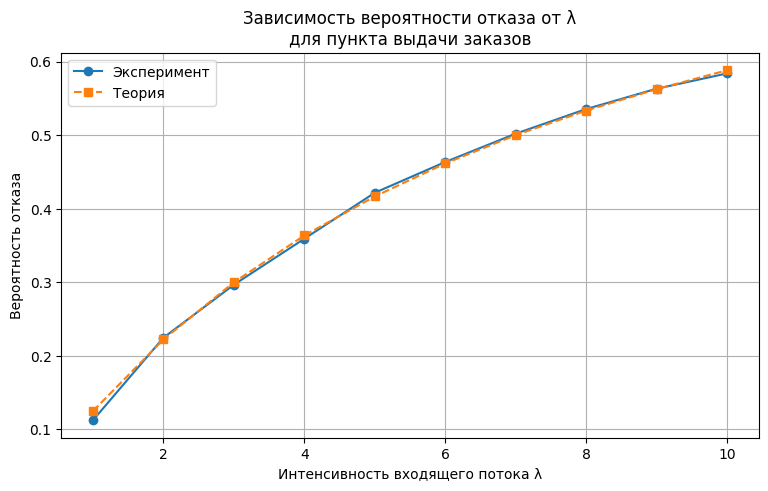

In [19]:

plt.figure(figsize=(9, 5))
plt.plot(lambdas, exp_refusal, marker='o', label='Эксперимент')
plt.plot(lambdas, theor_refusal, marker='s', linestyle='--', label='Теория')
plt.xlabel('Интенсивность входящего потока λ')
plt.ylabel('Вероятность отказа')
plt.title('Зависимость вероятности отказа от λ\nдля пункта выдачи заказов')
plt.grid(True)
plt.legend()
plt.show()



## 5. Краткий анализ результатов

По результатам моделирования можно сделать следующие выводы:

1. При увеличении интенсивности входящего потока $\lambda$ вероятность отказа возрастает.
2. Чем чаще приходят клиенты, тем больше доля времени, когда окно выдачи занято.
3. Экспериментальные значения близки к теоретическим, что подтверждает корректность построенной модели.
4. Для пункта выдачи заказов отсутствие очереди приводит к потерям клиентов уже при умеренной загрузке.

Таким образом, одноканальная система с отказами подходит только в ситуациях, когда поток клиентов невелик или высокая доля отказов допустима.
